In [21]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action='ignore', category=(SettingWithCopyWarning))
warnings.filterwarnings('ignore')

colormap = sns.color_palette("Blues")
sns.set_context("poster")
sns.set_palette("colorblind")
matplotlib.rcParams.update({'font.size': 22})
sns.set(font_scale=2.4)

In [22]:
AGENTS = [
    "Qwen/Qwen3-30B-A3B-Instruct-2507",
    "google/gemma-3-27b-it",
]
AGENTS_CLEAN_NAMES = ["Qwen3-30B", "Gemma-3-27B"]
rename_dict = dict(zip(AGENTS, AGENTS_CLEAN_NAMES))
rename_dict["Qwen/qwen3-30b-a3b-instruct-2507"] = "Qwen3-30B"

LOGS_ROOT = "../../../.logs/medium_models"

os.makedirs("../figures", exist_ok=True)

#### Utils

In [23]:
def load_games_from_dir(log_dir):
    records = []
    for root, dirs, files in os.walk(log_dir):
        if "game_state.json" not in files:
            continue
        path = os.path.join(root, "game_state.json")
        try:
            with open(path) as f:
                data = json.load(f)
            last = data["game_state"][-1]
            if last.get("current_iteration") != "END":
                continue
            summary = last["summary"]
            players = data["players"]
            records.append({
                "path": path,
                "game_class": data["class"],
                "model_1": players[0].get("model_id", players[0].get("model")),
                "model_2": players[1].get("model_id", players[1].get("model")),
                "summary": summary,
            })
        except Exception as e:
            print(f"Skipping {path}: {e}")
    print(f"Found {len(records)} completed games in {log_dir}")
    return records


def resource_value(res):
    return sum(res["_value"].values())


def replace_names(df):
    df = df.copy()
    df["model_1"] = df["model_1"].replace(rename_dict)
    df["model_2"] = df["model_2"].replace(rename_dict)
    return df

## Game Completion Rates

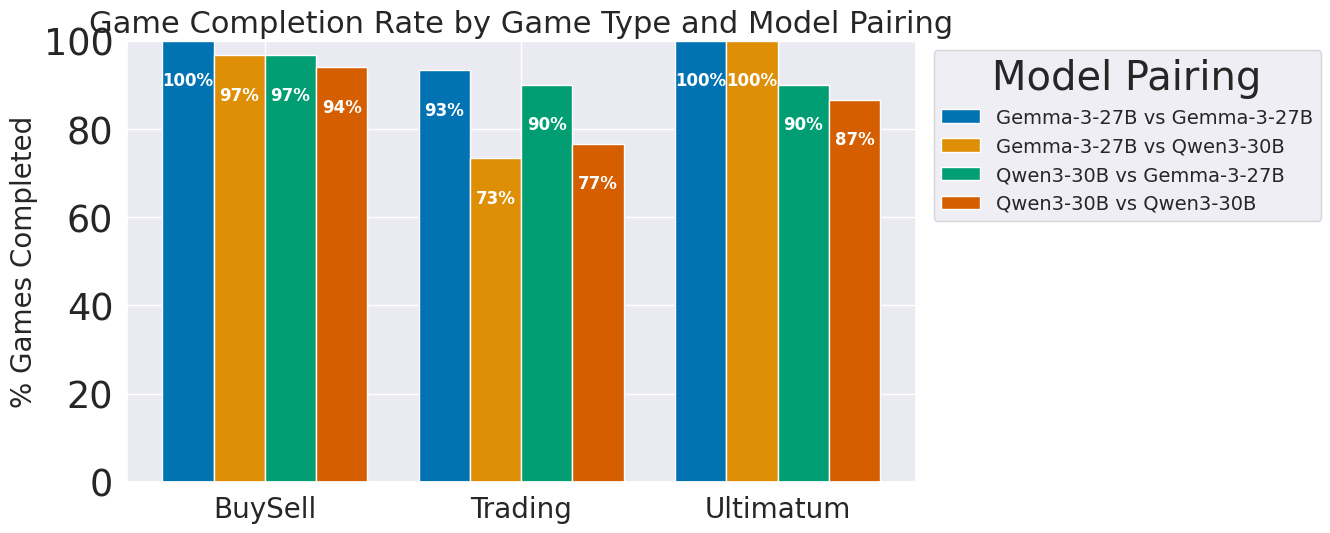

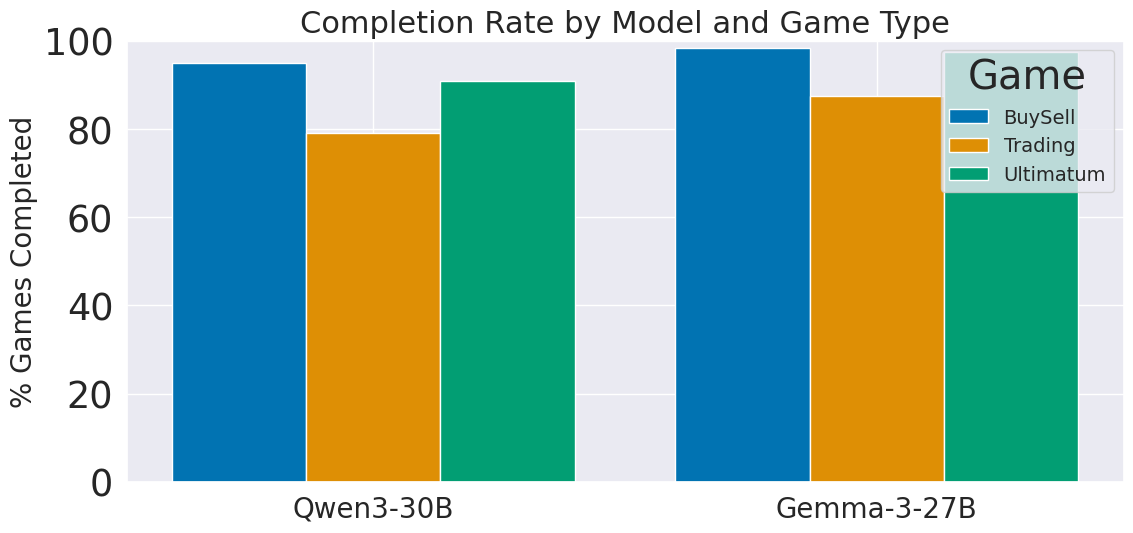

In [24]:
def load_completion_stats(log_dirs):
    """Count total vs completed games per model pairing for each game type."""
    rows = []
    for game_name, log_dir in log_dirs.items():
        for root, dirs, files in os.walk(log_dir):
            if "game_state.json" not in files:
                continue
            path = os.path.join(root, "game_state.json")
            try:
                with open(path) as f:
                    data = json.load(f)
                players = data["players"]
                last = data["game_state"][-1]
                completed = last.get("current_iteration") == "END"
                rows.append({
                    "game": game_name,
                    "model_1": players[0].get("model_id", players[0].get("model", "unknown")),
                    "model_2": players[1].get("model_id", players[1].get("model", "unknown")),
                    "completed": completed,
                })
            except Exception:
                pass
    return pd.DataFrame(rows)


log_dirs = {
    "Trading": os.path.join(LOGS_ROOT, "section_one/trading_section_one"),
    "Ultimatum": os.path.join(LOGS_ROOT, "section_one/ultimatum_section_one"),
    "BuySell": os.path.join(LOGS_ROOT, "section_one/buysell_section_one"),
}

df_raw = load_completion_stats(log_dirs)
df_raw["model_1"] = df_raw["model_1"].replace(rename_dict)
df_raw["model_2"] = df_raw["model_2"].replace(rename_dict)
df_raw["pairing"] = df_raw["model_1"] + " vs " + df_raw["model_2"]

agg = df_raw.groupby(["game", "pairing"]).agg(
    total=("completed", "count"),
    completed=("completed", "sum"),
).reset_index()
agg["pct"] = agg["completed"] / agg["total"] * 100

games = agg["game"].unique()
pairings = sorted(agg["pairing"].unique())
x = np.arange(len(games))
width = 0.8 / len(pairings)

fig, ax = plt.subplots(figsize=(14, 6))
colors = sns.color_palette("colorblind", len(pairings))

for i, pairing in enumerate(pairings):
    sub = agg[agg["pairing"] == pairing].set_index("game")
    vals = [sub.loc[g, "pct"] if g in sub.index else 0 for g in games]
    bars = ax.bar(x + i * width, vals, width, label=pairing, color=colors[i])
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val - 7,
            f"{val:.0f}%",
            ha="center", va="top", fontsize=12, color="white", fontweight="bold",
        )

ax.set_xticks(x + width * (len(pairings) - 1) / 2)
ax.set_xticklabels(games, fontsize=20)
ax.set_ylabel("% Games Completed", fontsize=20)
ax.set_title("Game Completion Rate by Game Type and Model Pairing", fontsize=22)
ax.set_ylim(0, 100)
ax.legend(title="Model Pairing", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=14)
fig.tight_layout()
#plt.savefig("../../figures/medium_completion_rate.pdf", bbox_inches="tight")
plt.show()

#  Per-model completion rate 
df_m1 = df_raw[["game", "model_1", "completed"]].rename(columns={"model_1": "model"})
df_m2 = df_raw[["game", "model_2", "completed"]].rename(columns={"model_2": "model"})
agg_model = (
    pd.concat([df_m1, df_m2])
    .groupby(["game", "model"])
    .agg(total=("completed", "count"), completed=("completed", "sum"))
    .reset_index()
)
agg_model["pct"] = agg_model["completed"] / agg_model["total"] * 100

games_list = sorted(agg_model["game"].unique())
models_list = AGENTS_CLEAN_NAMES
x2 = np.arange(len(models_list))
width2 = 0.8 / len(games_list)

fig2, ax2 = plt.subplots(figsize=(12, 6))
game_colors = sns.color_palette("colorblind", len(games_list))

for i, game in enumerate(games_list):
    sub = agg_model[agg_model["game"] == game].set_index("model")
    vals = [sub.loc[m, "pct"] if m in sub.index else 0 for m in models_list]
    ax2.bar(x2 + i * width2, vals, width2, label=game, color=game_colors[i])

ax2.set_xticks(x2 + width2 * (len(games_list) - 1) / 2)
ax2.set_xticklabels(models_list, fontsize=20)
ax2.set_ylabel("% Games Completed", fontsize=20)
ax2.set_title("Completion Rate by Model and Game Type", fontsize=22)
ax2.set_ylim(0, 100)
ax2.legend(title="Game", fontsize=14)
fig2.tight_layout()
#plt.savefig("../../figures/medium_completion_rate_by_model.pdf", bbox_inches="tight")
plt.show()



## Trading

In [25]:
records = load_games_from_dir(os.path.join(LOGS_ROOT, "section_one/trading_section_one"))

rows = []
for r in records:
    s = r["summary"]
    init = s["initial_resources"]
    final = s["final_resources"]
    delta_1 = resource_value(final[0]) - resource_value(init[0])
    delta_2 = resource_value(final[1]) - resource_value(init[1])
    rows.append({
        "game_name": r["game_class"],
        "model_1": r["model_1"],
        "model_2": r["model_2"],
        "resource_delta_1": delta_1,
        "resource_delta_2": delta_2,
    })

trading_df = replace_names(pd.DataFrame(rows))
trading_df.head()

Found 100 completed games in ../../../.logs/medium_models/section_one/trading_section_one


,game_name,model_1,model_2,resource_delta_1,resource_delta_2
0,TradingGame,Qwen3-30B,Gemma-3-27B,0,0
1,TradingGame,Qwen3-30B,Gemma-3-27B,7,-7
2,TradingGame,Qwen3-30B,Gemma-3-27B,5,-5
3,TradingGame,Qwen3-30B,Gemma-3-27B,-2,2
4,TradingGame,Qwen3-30B,Gemma-3-27B,8,-8


In [26]:
print("Total trading games:", len(trading_df))
print("Games per pairing:")
print(trading_df.groupby(["model_1", "model_2"]).size().to_string())

Total trading games: 100
Games per pairing:
model_1      model_2    
Gemma-3-27B  Gemma-3-27B    28
             Qwen3-30B      22
Qwen3-30B    Gemma-3-27B    27
             Qwen3-30B      23


In [27]:
def trading_aggregation(df):
    df = df.copy()
    df["models"] = df["model_1"] + "@" + df["model_2"]
    df["win_1"] = df["resource_delta_1"] > df["resource_delta_2"]
    df["win_2"] = df["resource_delta_1"] < df["resource_delta_2"]

    agg = df.groupby(["game_name", "models"])[
        ["win_1", "win_2", "resource_delta_1", "resource_delta_2"]
    ].mean().reset_index()

    agg[["model_1", "model_2"]] = agg["models"].str.split("@", n=1, expand=True)
    total_decisive = agg["win_1"] + agg["win_2"]
    agg["win_1"] = agg["win_1"] / total_decisive
    agg["win_2"] = agg["win_2"] / total_decisive
    return agg


aggregated = trading_aggregation(trading_df)
aggregated

,game_name,models,win_1,win_2,resource_delta_1,resource_delta_2,model_1,model_2
0,TradingGame,Gemma-3-27B@Gemma-3-27B,0.166667,0.833333,-3.785714,3.785714,Gemma-3-27B,Gemma-3-27B
1,TradingGame,Gemma-3-27B@Qwen3-30B,0.000000,1.000000,-5.000000,5.000000,Gemma-3-27B,Qwen3-30B
2,TradingGame,Qwen3-30B@Gemma-3-27B,0.900000,0.100000,3.296296,-3.296296,Qwen3-30B,Gemma-3-27B
3,TradingGame,Qwen3-30B@Qwen3-30B,0.250000,0.750000,-0.652174,0.652174,Qwen3-30B,Qwen3-30B


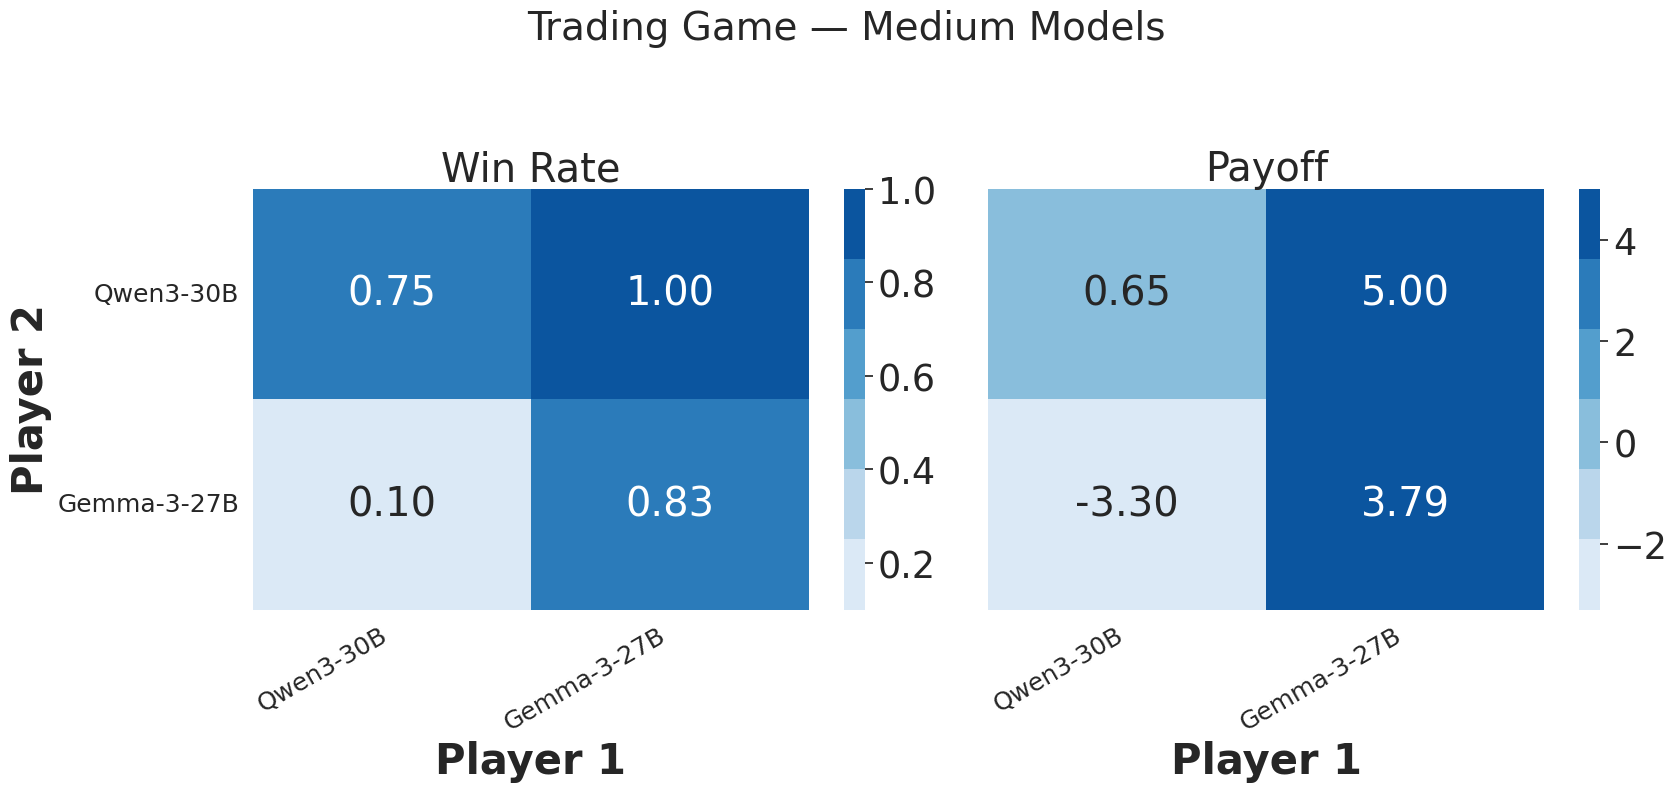

In [28]:
fig, axs = plt.subplots(figsize=(17.6, 8), ncols=2)
fig.tight_layout()

# Win Rate heatmap
local = aggregated.pivot(index="model_2", columns="model_1", values="win_2")
local = local.reindex(AGENTS_CLEAN_NAMES, axis=1).reindex(AGENTS_CLEAN_NAMES)

p1 = sns.heatmap(local, annot=True, fmt=".2f", cmap=colormap, ax=axs[0])
p1.set_ylabel("Player 2", fontdict=dict(weight="bold", size=30))
p1.set_xlabel("Player 1", fontdict=dict(weight="bold", size=30))
p1.set_title("Win Rate")
p1.set_xticklabels(AGENTS_CLEAN_NAMES, rotation=30, ha="right", fontsize=18)
p1.set_yticklabels(AGENTS_CLEAN_NAMES, rotation=0, va="center", fontsize=18)

# Payoff heatmap
local = aggregated.pivot(index="model_2", columns="model_1", values="resource_delta_2")
local = local.reindex(AGENTS_CLEAN_NAMES, axis=1).reindex(AGENTS_CLEAN_NAMES)

p2 = sns.heatmap(local, annot=True, fmt=".2f", cmap=colormap, ax=axs[1])
p2.set_ylabel("")
p2.set_xlabel("Player 1", fontdict=dict(weight="bold", size=30))
p2.set_title("Payoff")
p2.set_xticklabels(AGENTS_CLEAN_NAMES, rotation=30, ha="right", fontsize=18)
p2.set_yticklabels([], fontsize=18)

fig.suptitle("Trading Game — Medium Models", fontsize=28, y=1.02)
fig.tight_layout()
#plt.savefig("../../figures/medium_trading.pdf", bbox_inches="tight")
plt.show()

## Ultimatum

In [29]:
records = load_games_from_dir(os.path.join(LOGS_ROOT, "section_one/ultimatum_section_one"))

rows = []
for r in records:
    s = r["summary"]
    init = s["initial_resources"]
    final = s["final_resources"]
    delta_1 = resource_value(final[0]) - resource_value(init[0])
    delta_2 = resource_value(final[1]) - resource_value(init[1])
    rows.append({
        "game_name": r["game_class"],
        "model_1": r["model_1"],
        "model_2": r["model_2"],
        "resource_delta_1": delta_1,
        "resource_delta_2": delta_2,
    })

ultimatum_df = replace_names(pd.DataFrame(rows))

ultimatum_df["resource_delta_1"] = ultimatum_df["resource_delta_1"] + 100
ultimatum_df.loc[ultimatum_df["resource_delta_1"] == 100, "resource_delta_1"] = 0

ultimatum_df.head()

Found 113 completed games in ../../../.logs/medium_models/section_one/ultimatum_section_one


,game_name,model_1,model_2,resource_delta_1,resource_delta_2
0,MultiTurnUltimatumGame,Qwen3-30B,Gemma-3-27B,80,20
1,MultiTurnUltimatumGame,Qwen3-30B,Gemma-3-27B,99,1
2,MultiTurnUltimatumGame,Qwen3-30B,Gemma-3-27B,99,1
3,MultiTurnUltimatumGame,Qwen3-30B,Gemma-3-27B,99,1
4,MultiTurnUltimatumGame,Qwen3-30B,Gemma-3-27B,80,20


In [30]:
print("Total ultimatum games:", len(ultimatum_df))
print("\nGames per pairing:")
print(ultimatum_df.groupby(["model_1", "model_2"]).size().to_string())
print("\nNo-deal rate per pairing:")
no_deal = ultimatum_df.copy()
no_deal["no_deal"] = (no_deal["resource_delta_1"] == 0) & (no_deal["resource_delta_2"] == 0)
print(no_deal.groupby(["model_1", "model_2"])["no_deal"].mean().to_string())

Total ultimatum games: 113

Games per pairing:
model_1      model_2    
Gemma-3-27B  Gemma-3-27B    30
             Qwen3-30B      30
Qwen3-30B    Gemma-3-27B    27
             Qwen3-30B      26

No-deal rate per pairing:
model_1      model_2    
Gemma-3-27B  Gemma-3-27B    0.333333
             Qwen3-30B      0.033333
Qwen3-30B    Gemma-3-27B    0.000000
             Qwen3-30B      0.038462


In [31]:
def ultimatum_aggregation(df):
    df = df.copy()
    df["models"] = df["model_1"] + "@" + df["model_2"]
    df["win_1"] = df["resource_delta_1"] > df["resource_delta_2"]
    df["win_2"] = df["resource_delta_1"] < df["resource_delta_2"]

    agg = df.groupby(["game_name", "models"])[
        ["win_1", "win_2", "resource_delta_1", "resource_delta_2"]
    ].mean().reset_index()

    agg[["model_1", "model_2"]] = agg["models"].str.split("@", n=1, expand=True)
    total_decisive = agg["win_1"] + agg["win_2"]
    agg["win_1"] = agg["win_1"] / total_decisive
    agg["win_2"] = agg["win_2"] / total_decisive
    return agg


aggregated = ultimatum_aggregation(ultimatum_df)
aggregated

,game_name,models,win_1,win_2,resource_delta_1,resource_delta_2,model_1,model_2
0,MultiTurnUltimatumGame,Gemma-3-27B@Gemma-3-27B,0.888889,0.111111,41.666667,25.000000,Gemma-3-27B,Gemma-3-27B
1,MultiTurnUltimatumGame,Gemma-3-27B@Qwen3-30B,0.961538,0.038462,79.000000,17.666667,Gemma-3-27B,Qwen3-30B
2,MultiTurnUltimatumGame,Qwen3-30B@Gemma-3-27B,1.000000,0.000000,84.518519,15.481481,Qwen3-30B,Gemma-3-27B
3,MultiTurnUltimatumGame,Qwen3-30B@Qwen3-30B,1.000000,0.000000,73.730769,22.423077,Qwen3-30B,Qwen3-30B


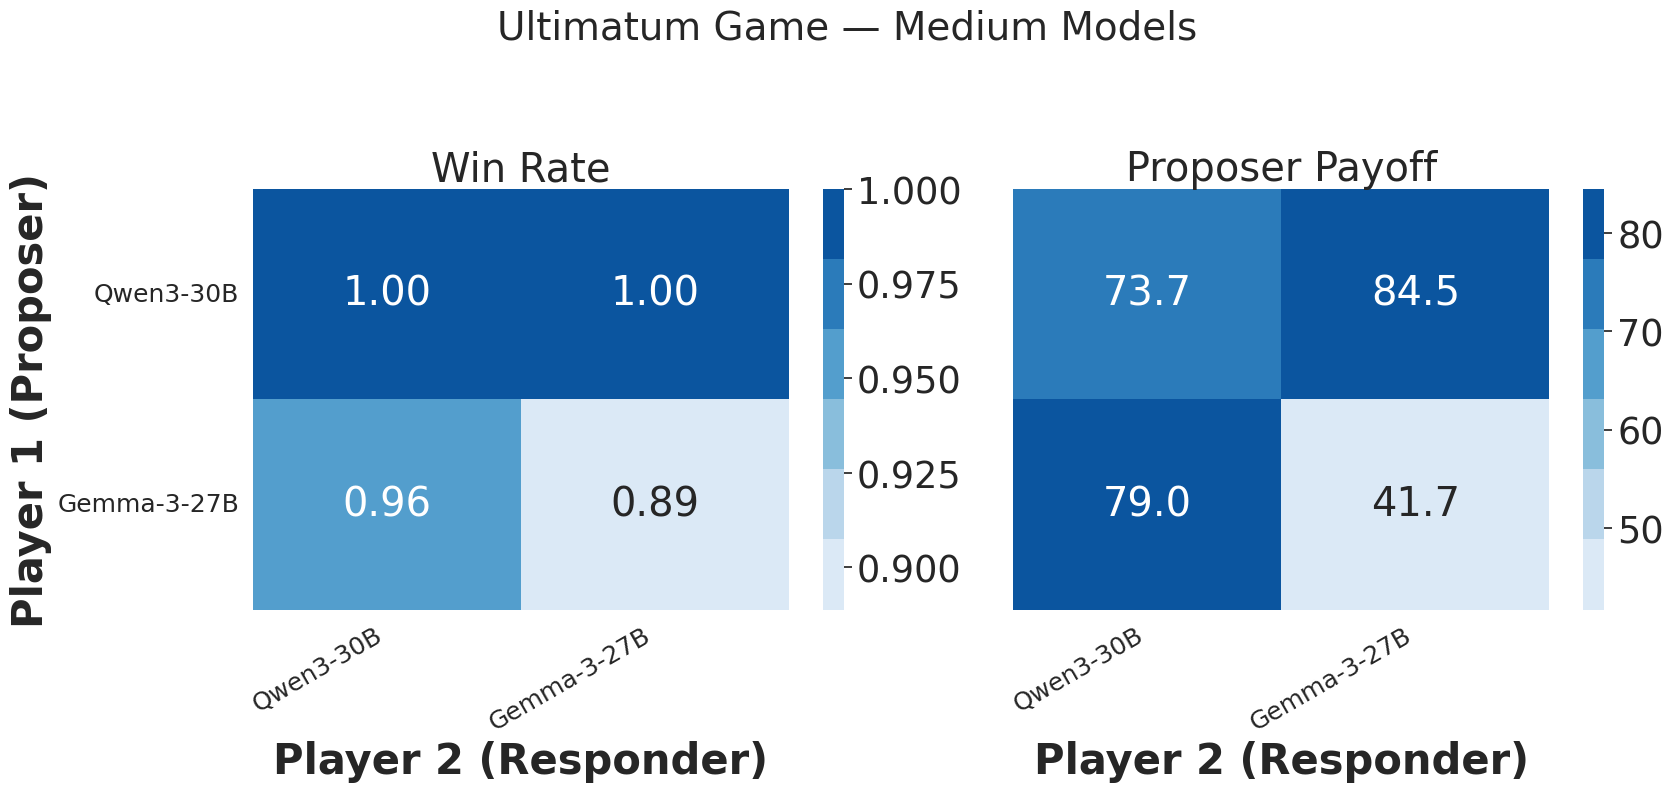

In [32]:
fig, axs = plt.subplots(figsize=(17.6, 8), ncols=2)

# Win Rate heatmap (P1 perspective: P1 is proposer)
local = aggregated.pivot(index="model_1", columns="model_2", values="win_1")
local = local.reindex(AGENTS_CLEAN_NAMES, axis=1).reindex(AGENTS_CLEAN_NAMES)

p1 = sns.heatmap(local, annot=True, fmt=".2f", cmap=colormap, ax=axs[0])
p1.set_title("Win Rate")
p1.set_ylabel("Player 1 (Proposer)", fontdict=dict(weight="bold", size=30))
p1.set_xlabel("Player 2 (Responder)", fontdict=dict(weight="bold", size=30))
p1.set_xticklabels(AGENTS_CLEAN_NAMES, rotation=30, ha="right", fontsize=18)
p1.set_yticklabels(AGENTS_CLEAN_NAMES, rotation=0, va="center", fontsize=18)

# Payoff heatmap
local = aggregated.pivot(index="model_1", columns="model_2", values="resource_delta_1")
local = local.reindex(AGENTS_CLEAN_NAMES, axis=1).reindex(AGENTS_CLEAN_NAMES)

p2 = sns.heatmap(local, annot=True, fmt=".1f", cmap=colormap, ax=axs[1])
p2.set_ylabel("")
p2.set_xlabel("Player 2 (Responder)", fontdict=dict(weight="bold", size=30))
p2.set_title("Proposer Payoff")
p2.set_xticklabels(AGENTS_CLEAN_NAMES, rotation=30, ha="right", fontsize=18)
p2.set_yticklabels([], fontsize=18)

fig.suptitle("Ultimatum Game — Medium Models", fontsize=28, y=1.02)
fig.tight_layout()
#plt.savefig("../../figures/medium_ultimatum.pdf", bbox_inches="tight")
plt.show()

## Seller and Buyer

In [33]:
records = load_games_from_dir(os.path.join(LOGS_ROOT, "section_one/buysell_section_one"))

rows = []
for r in records:
    s = r["summary"]
    outcome = s["player_outcome"]
    vals = s["player_valuation"]
    val_1 = vals[0]["_value"]["X"] if vals and vals[0] else None
    val_2 = vals[1]["_value"]["X"] if vals and vals[1] else None
    rows.append({
        "game_name": r["game_class"],
        "model_1": r["model_1"],
        "model_2": r["model_2"],
        "outcome_1": outcome[0],
        "outcome_2": outcome[1],
        "vals1": val_1,
        "vals2": val_2,
    })

buysell_df = replace_names(pd.DataFrame(rows))
buysell_df.head()

Found 135 completed games in ../../../.logs/medium_models/section_one/buysell_section_one


,game_name,model_1,model_2,outcome_1,outcome_2,vals1,vals2
0,BuySellGame,Qwen3-30B,Gemma-3-27B,-6,26,40,60
1,BuySellGame,Qwen3-30B,Gemma-3-27B,5,15,40,60
2,BuySellGame,Qwen3-30B,Gemma-3-27B,-5,25,40,60
3,BuySellGame,Qwen3-30B,Gemma-3-27B,5,15,40,60
4,BuySellGame,Qwen3-30B,Gemma-3-27B,0,20,40,60


In [34]:
print("Total buy-sell games:", len(buysell_df))
print("\nAvailable seller valuations:", sorted(buysell_df["vals1"].unique()))

gb = buysell_df.groupby("vals1")
groups = {k: v.copy() for k, v in gb}

print("\nGames per valuation x pairing:")
for val, gdf in sorted(groups.items()):
    print(f"  Seller valuation={val}:")
    print(gdf.groupby(["model_1", "model_2"]).size().to_string())

Total buy-sell games: 135

Available seller valuations: [40]

Games per valuation x pairing:
  Seller valuation=40:
model_1      model_2    
Gemma-3-27B  Gemma-3-27B    30
             Qwen3-30B      29
Qwen3-30B    Gemma-3-27B    29
             Qwen3-30B      47


Seller at 40 (buyer at 60): 135 games
Filtered 0 outlier games


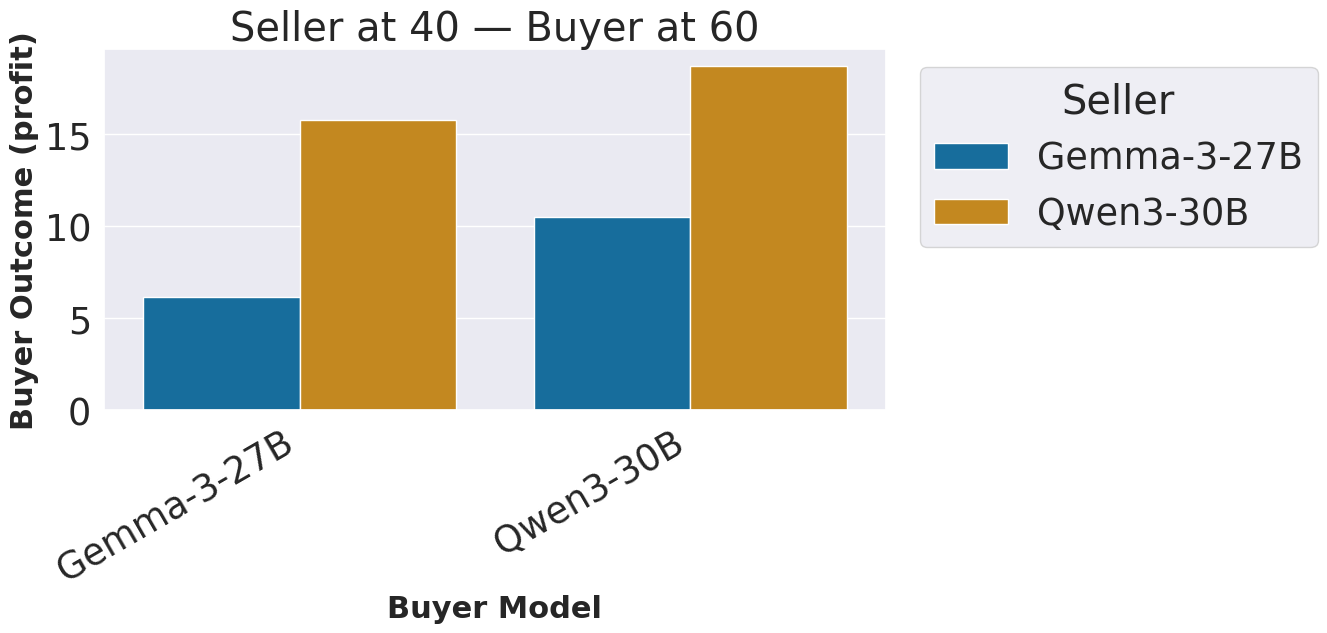

     seller       buyer  outcome_mean  outcome_sem  n
Gemma-3-27B Gemma-3-27B      6.166667     1.167651 30
Gemma-3-27B   Qwen3-30B     10.517241     0.918637 29
  Qwen3-30B Gemma-3-27B     15.793103     1.314357 29
  Qwen3-30B   Qwen3-30B     18.723404     0.736709 47


In [35]:
seller_at_40 = groups.get(40, pd.DataFrame())
print(f"Seller at 40 (buyer at 60): {len(seller_at_40)} games")

# Filter broken games: buyer profit ∈ [-100, 60]
valid = seller_at_40[
    (seller_at_40["outcome_2"] >= -100) & (seller_at_40["outcome_2"] <= 60)
]
print(f"Filtered {len(seller_at_40) - len(valid)} outlier games")

agg = (
    valid.groupby(["model_1", "model_2"])["outcome_2"]
    .agg(["mean", "sem", "count"])
    .reset_index()
)
agg.columns = ["seller", "buyer", "outcome_mean", "outcome_sem", "n"]
agg = agg[agg["n"] >= 2]

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(
    data=agg, x="buyer", y="outcome_mean", hue="seller",
    palette="colorblind", capsize=0.1, ax=ax
)
ax.set_ylabel("Buyer Outcome (profit)", fontdict=dict(weight="bold", size=22))
ax.set_xlabel("Buyer Model", fontdict=dict(weight="bold", size=22))
ax.set_title("Seller at 40 — Buyer at 60")
ax.legend(title="Seller", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

fig.tight_layout()
fig.savefig("../figures/medium_seller_at_40.pdf", bbox_inches="tight")
plt.show()

print(agg.to_string(index=False))

### Buy-Sell — Outcome Heatmaps

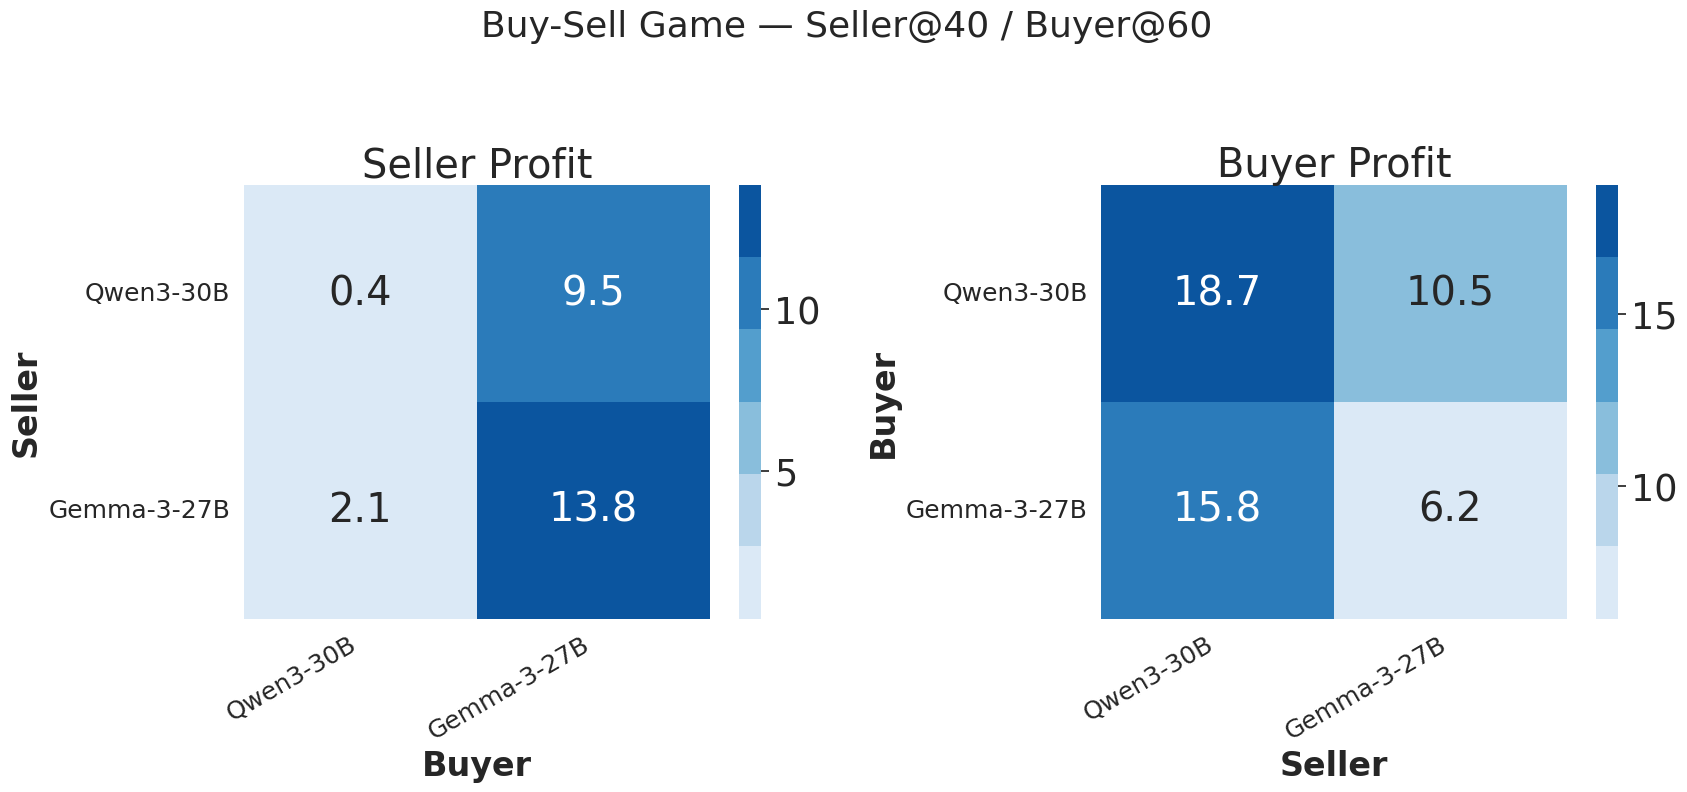

In [36]:
if len(valid) > 0:
    fig, axs = plt.subplots(figsize=(17.6, 8), ncols=2)

    for ax, (col, title) in zip(axs, [("outcome_1", "Seller Profit"), ("outcome_2", "Buyer Profit")]):
        pivot_data = valid.groupby(["model_1", "model_2"])[col].mean().reset_index()
        pivot = pivot_data.pivot(index="model_2", columns="model_1", values=col)
        pivot = pivot.reindex(AGENTS_CLEAN_NAMES, axis=1).reindex(AGENTS_CLEAN_NAMES)

        sns.heatmap(pivot, annot=True, fmt=".1f", cmap=colormap, ax=ax)
        ax.set_title(title)
        ax.set_ylabel("Buyer" if col == "outcome_2" else "Seller",
                      fontdict=dict(weight="bold", size=24))
        ax.set_xlabel("Seller" if col == "outcome_2" else "Buyer",
                      fontdict=dict(weight="bold", size=24))
        ax.set_xticklabels(AGENTS_CLEAN_NAMES, rotation=30, ha="right", fontsize=18)
        ax.set_yticklabels(AGENTS_CLEAN_NAMES, rotation=0, va="center", fontsize=18)

    fig.suptitle("Buy-Sell Game — Seller@40 / Buyer@60", fontsize=26, y=1.02)
    fig.tight_layout()
    #plt.savefig("../../figures/medium_buysell_heatmap.pdf", bbox_inches="tight")
    plt.show()